In [23]:
import pandas as pd
import matplotlib.pyplot as plt # viz
import seaborn as sns # better viz

Part 1: Undersdtanding Product Categories

In [107]:
df_og = pd.read_csv("dataset/amz_uk_price_prediction_dataset.csv")
df_og.head(10)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673,39.99,False,0,Hi-Fi Speakers
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909,29.99,False,0,Hi-Fi Speakers
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014,29.99,False,0,Hi-Fi Speakers


In [22]:
# Frequency Tables
df_cat = df_og["category"].value_counts().reset_index()
df_cat = df_cat.sort_values(by="count",ascending=False)
df_cat.head(5)

## Note to self: this can all be done in one line but it's cleaner in multiple lines
## df_og["category"].value_counts().reset_index().sort_values(by="count",ascending=False).head(3)

,category,count
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978


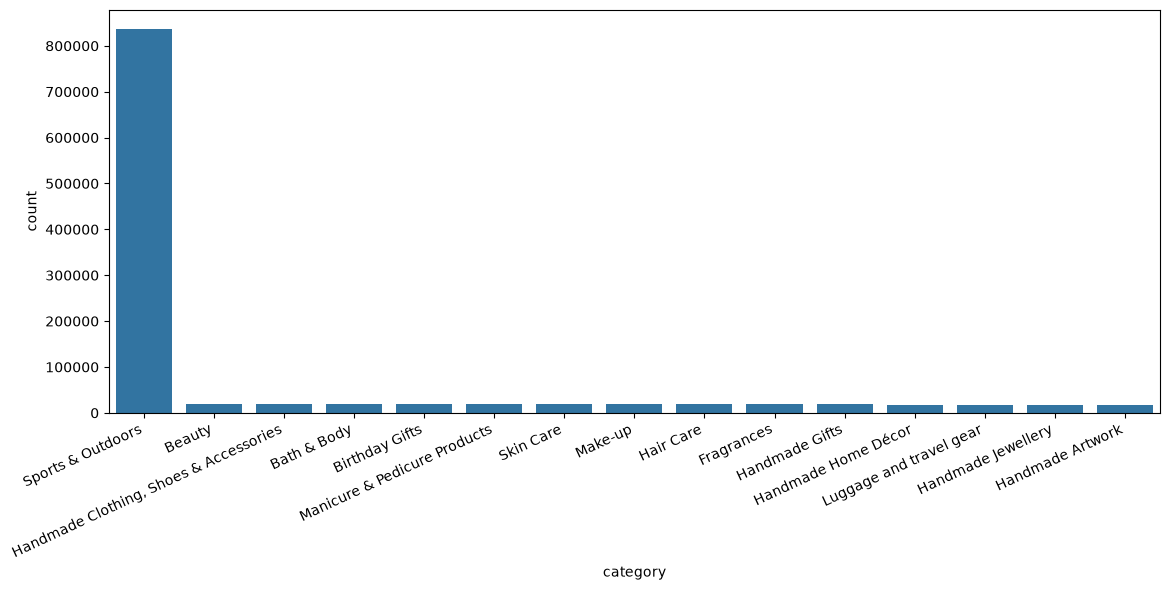

In [38]:
# Visualizations

## Bar Chart for a subset of categories

subset_cat = df_cat.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(
    x="category",
    y="count",
    data=subset_cat
)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


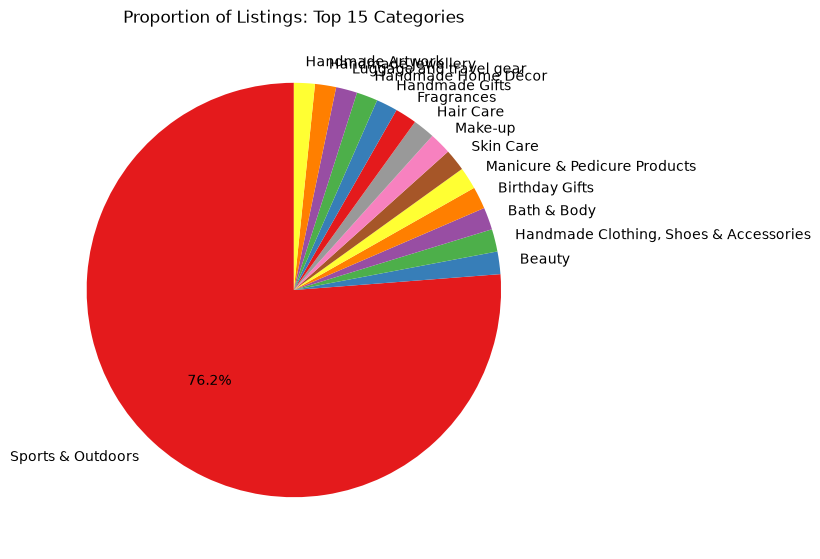

In [43]:
## Bar Chart

plt.figure(figsize=(8, 8))
subset_cat.set_index("category")["count"].plot.pie(
    autopct=lambda p: f'{p:.1f}%' if p >= 5 else '', 
    startangle=90,
    colors=sns.color_palette("Set1")
)
plt.ylabel("")  # removes the default "count" y-label pandas adds
plt.title("Proportion of Listings: Top 15 Categories")
plt.tight_layout()
plt.show()

1. The top 5 most listed product categories are: Sports&Outdoors, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body, Birthday Gifts
2. From both visualizations, it's visible that the Sports & Outdoors category dominates the listings.		

Part 2: Delving into Product Pricing

In [ ]:
# Measures of Centrality for Price

## Mean, Median, Mode for price for products

prod_price = df_og[["price","category"]]
prod_price

mean_price = prod_price["price"].mean().round(2)
median_price = prod_price["price"].median().round(2)
mode_price = prod_price["price"].mode().iloc[0].round(2)
print(f"Mean price: {mean_price}, Median price: {median_price}, Mode price: {mode_price}")

Mean price: 89.24, Median price: 19.09, Mode price: 9.99


1. The average price point is ~90 pounds. However, compared to the most common value, i.e. the mode, it's a significant difference, as the mode is ~10 pounds. Based on the data so far, because of the category popularity, it seems that the higher priced products are drawing the mean towards higher value. 

In [ ]:
## Measures of Dispersion for Price

dispersion = prod_price["price"].describe().round(2)
var_price = prod_price["price"].var().round(2)
std_price = prod_price["price"].std().round(2)
range_price = prod_price["price"].max().round(2) - prod_price["price"].min().round(2)
iqr_price = prod_price["price"].quantile(0.75) - prod_price["price"].quantile(0.25)

print(
    f"The measures of dispersion for price, Variance: {var_price}, Standard Deviation: {std_price}, Range: {range_price}, Interquartile Range: {iqr_price}"
)


The measures of dispersion for price, Variance: 119445.49, Standard Deviation: 345.61, Range: 100000.0, Interquartile Range: 36.0


2. The product prices seem to be highly varied, based on the range which is the maximum miuns the minimum price, and as seen above the value is 100000. The standard deviation indicates that most products fall 345.61 pounds above or below the mean. The variance here is another indicator how wide the spread is. The interquartile range indicates that the middle 50% of the prices are around 36 pounds. 

In [ ]:
## Visualizations for Price

q1 = prod_price["price"].quantile(0.25)
q3 = prod_price["price"].quantile(0.75)
print(f"Middle 50% of the products fall between {q1:.2f} and {q3:.2f} pounds.")

Middle 50% of the products fall between 9.99 and 45.99 pounds.


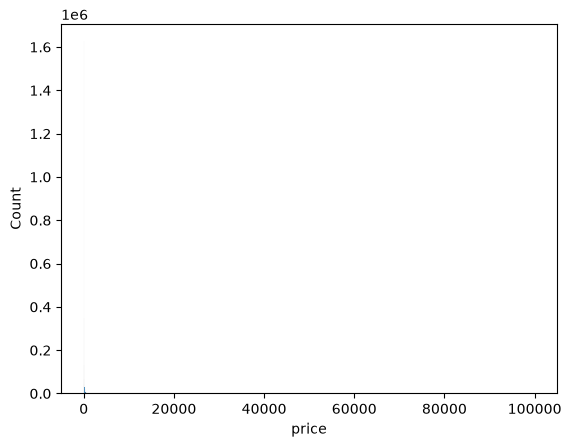

In [73]:
sns.histplot(df_og["price"], bins="auto")
plt.show()

It's almost impossible to read the plot above. The prices are right-skewed almost around the 0, because a few extreme outliers around 100,000 pounds are stretching out the dataset. 

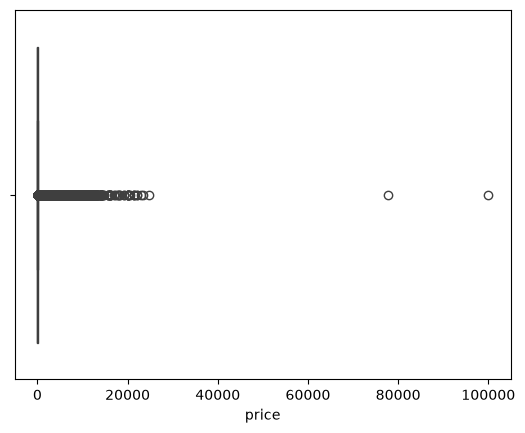

In [78]:
sns.boxplot(x=df_og["price"])
plt.show()

This boxplot confirms the assumtion that there are some extreme outliers as seen in the figure above, two extreme outliers lie around prices of 80K and 100K pounds.

Part 3: Unpacking Product Ratings

In [96]:
# Measures of Centrality for Ratings

## Mean, Median, Mode for product ratings

prod_rating = df_og[df_og["stars"] > 0]["stars"] # Products with stars = 0 i.e. no product results are excluded from the analysis
prod_rating


mean_rating = prod_rating.mean().round(2)
median_rating = prod_rating.median().round(2)
mode_rating = prod_rating.mode().iloc[0].round(2)
print(f"Mean rating: {mean_rating}, Median rating: {median_rating}, Mode rating: {mode_rating}")

Mean rating: 4.32, Median rating: 4.4, Mode rating: 4.5


From the results above, we can see that there isn't a great difference between the mean, median, and mode. This indicates that products are generally rated around 4 stars.

In [99]:
# Measures of Dispersion for Ratings

dispersion = prod_rating.describe().round(2)
var_rating = prod_rating.var().round(2)
std_rating = prod_rating.std().round(2)
range_rating = prod_rating.max().round(2) - prod_rating.min().round(2)
iqr_rating = prod_rating.quantile(0.75) - prod_rating.quantile(0.25)

print(
    f"The measures of dispersion for ratings, Variance: {var_rating}, Standard Deviation: {std_rating}, Range: {range_rating}, Interquartile Range: {iqr_rating}"
)

The measures of dispersion for ratings, Variance: 0.31, Standard Deviation: 0.56, Range: 4.0, Interquartile Range: 0.5


The results form the dispersion for ratings, indicate that the variance in customer feedback is generally very low. This can also be confirmed by looking at the standard deviation which indicates that the reviews are generally 0.56 starts above or below the mean. 

In [100]:
#Shape of the distribution

skewness = prod_rating.skew().round(2)
kurtosis = prod_rating.kurt().round(2)

print(
    f"The shape of the distribution for ratings, Skewnewss: {skewness}, Kurtosis: {kurtosis}"
)

The shape of the distribution for ratings, Skewnewss: -2.38, Kurtosis: 9.78


Becuase the skewnewss is negative, this means that the data is left-skewed and they lean toward higher values. 

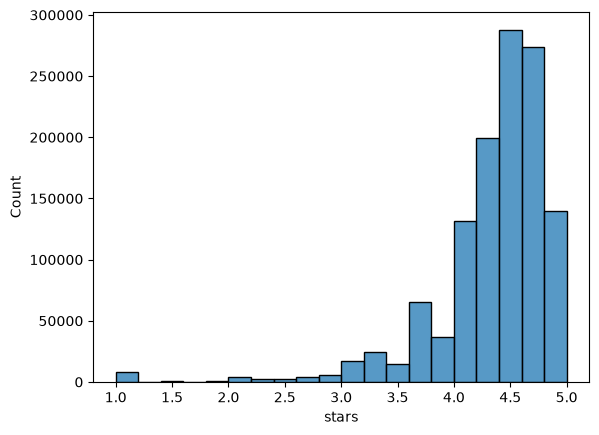

In [106]:
sns.histplot(data=prod_rating, bins = 20)
plt.show()

The ratings around 4.5 seem to be the most common as seen in the visualization above.